# Kernel-based training of quantum models with scikit-learn

Following: https://pennylane.ai/qml/demos/tutorial_kernel_based_training

Questions:
* What is a quantum node, exactly?
* What is a fixed embedding circuit?
* What's the difference between differentiation methods?
    * `diff_method='parameter-shift'`
        * You can't use standard backpropagation through a quantum circuit the way you would in PyTorch or TensorFlow — quantum operations don't have a simple computational graph that autodiff can traverse. 
        * Instead, PennyLane uses a trick: to find the gradient with respect to a parameter $\theta$, it runs the circuit **twice** with the parameter shifted slightly in each direction
        * $\frac{\partial f}{\partial \theta} = \frac{f(\theta + \pi / 2) - f(\theta - \pi / 2)}{2}$
        * The gradient is just the difference between those two results. This is the parameter-shift rule.
    * backprop
    * adjoint
* What does it mean to train *f* variationally?
    * This idea of variational training, or variational quantum circuits, or variational quantum algorithms (etc.) seems to come up again and again. It's probably important

### Background

Consider a *quantum model* of the form $f(x)=\braket{\phi(x) | \mathcal{M} | \phi(x)}$
* $\ket{\phi(x)}$ is prepared by a fixed embedding circuit [[??]](https://pennylane.ai/qml/glossary/quantum_embedding) that encodes the $x$ data inputs
* $\mathcal{M}$ is an arbitrary observable

This quantum model includes variational QML models, because the observable can effectively be implemented by a simple measure that is preceded by a variational circuit

[the docs have a nice QC circuit image here, and then they claim that applying circuit $G(\theta)$ followed by measuring the Pauli-Z observable $\sigma^{0}_{z}$ (i.e. measuring in the 0/1 basis), that this implements the trainable measurement $\mathcal{M} = G^{\dagger}(\theta)\sigma^{0}_{z}G(\theta)$ ]

When we approach QML with a kernel approach, instead of training $f$ variationally [what does this mean?], we can train an equivalent classical kernel method with a kernel executed on a quantum device. This *quantum kernel* is given by the mutual overlap of two data-encoding quantum states:

$\kappa(x, x') = \left|\braket{\phi(x') | \phi(x)}\right|^2$

Kernel-based training bypasses the processing and measurement parts of common variational circuits, and it only depends on the data encoding

If the loss function $L$ is the hinge loss, then the kernel method corresponds to a standard SVM because it is a maximum-margin classifier. Other convex loss functions lead to more general variations of SVMs

## Kernel-Based Training

First we turn to kernel-based training of quantum models, e.g. a standard SVM with a kernel computed by a quantum circuit.

We're going to import a bunch of libraries and then set up the famed `iris` dataset

In [17]:
import numpy as np
import torch
from torch.nn.functional import relu

from sklearn.svm import SVC
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import pennylane as qml
from pennylane.templates import AngleEmbedding, StronglyEntanglingLayers

import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
#load the iris dataset and preprocess it
X, y = load_iris(return_X_y=True)

# pick inputs and labels from the first two classes only,
# corresponding to the first 100 samples
X = X[:100]
y = y[:100]

# scaling the inputs is important because the embedding we use is periodic
scaler = StandardScaler().fit(X)
X_scaled = scaler.transform(X)

# scaling the labels to -1, 1 is important for the SVM and the
# definition of a hinge loss
y_scaled = 2 * (y - 0.5)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled)

In [19]:
#we use the angle-embedding template which needs the number of features to be equal to the number of qubits
n_qubits = len(X_train[0])
print(n_qubits)

4


To implement the kernel we would normally prepare the two states $\ket{\phi(x)}$ and $\ket{\phi(x')}$ on different sets of qubits with angle-embedding routines $S(x)$ and $S(x')$, then measure their overlap with a routine called a SWAP test

But we can actually prepare $\ket{\phi(x)}$ and then apply the inverse embedding with $x'$ on the same qubits, which means we only need half the number of qubits. We then measure the projector onto the initial state $\ket{0...0}\bra{0...0}$

We verify this gives us the kernel:

$\braket{ 0...0 | S(x')S(x)^{\dagger} \mathcal{M} S(x')^{\dagger}S(x) | 0...0} =$

###### (I do not know how this is equivalent to next line)

$=\braket{0...0|S(x')S(x)^{\dagger}|0...0}\braket{0...0|S(x')^{\dagger}S(x)|0...0}$ 

$=\left|\braket{0...0|S(x')^{\dagger}S(x)|0...0}\right|^2$

$=\left| \braket{\phi(x') | \phi(x)} \right|$

$= \kappa(x, x')$

Note that a projector $\ket{0...0}\bra{0...0}$ can be constructed using the `qml.Hermitian` observable in Penny Lane. In any case, we use the following quantum node as a *quantum kernel evaluator:*


In [20]:
dev_kernel = qml.device('lightning.qubit', wires=n_qubits)

projector = np.zeros((2 ** n_qubits, 2 ** n_qubits))
projector[0, 0] = 1

@qml.qnode(dev_kernel)
def kernel(x1, x2):
    AngleEmbedding(x1, wires=range(n_qubits))
    qml.adjoint(AngleEmbedding)(x2, wires=range(n_qubits))
    return qml.expval(qml.Hermitian(projector, wires=range(n_qubits)))

In [21]:
#sanity check: the kernel of a vector with itself should be 1
print(kernel(X_train[0], X_train[0]))

0.9999999999999998


When working with a custom SVM kernel implemented in `sklearn`, we need a function that computes a matrix of kernel evaluations for samples in two different datasets $A$ and $B$. If $A=B$ this is the Gram matrix ([a Hermitian matrix of inner products](https://en.wikipedia.org/wiki/Gram_matrix))

In [22]:
def kernel_matrix(A, B):
    """Compute the matrix whose entries are the kernel evaluated on
    pairwise data from sets A and B"""
    return np.array([[kernel(a, b) for b in B] for a in A])

Training the SVM optimizes internal parameters that weigh kernel functions, and it's easy to implement in `sklearn`:

In [23]:
svm = SVC(kernel=kernel_matrix)
svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",<function ker...t 0x1194bc4a0>
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [24]:
with dev_kernel.tracker:
    predictions = svm.predict(X_test)
    accuracy_score(predictions, y_test)

In [28]:
#this time without specifying the dev_kernel
predictions = svm.predict(X_test)
accuracy_score(predictions, y_test)

1.0

In [29]:
#how many times did we execute the quantum device kernel?
dev_kernel.tracker.totals['executions']

1875

This number of executions is derived as follows:

For $M$ training samples, the SVM constructs a kernel gram matrix with $M \times M$ dimensions. To classify $M_{pred}$ new samples, the SVM must evaluate $M_{pred} \cdot M$ times (at most) to get the pairwise distances between training vectors and test samples

Note: depending on the SVM implementation, only $S \leq M_{pred}$ support vectors are needed

We formulate this as a function below, which can be also be used at the end of the demo to construct a scaling plot

In [32]:
def circuit_evals_kernel(n_data, split):
    """Compute how many circuit evaluations you need for
    kernel-based training and prediction"""

    M = int(np.ceil(split * n_data))
    Mpred = n_data - M

    n_training = M * M
    n_prediction = M * Mpred

    return n_training + n_prediction

In [37]:
#with M=75 and Mpred=25, the number of kernel evaluations is estimated as:

circuit_evals_kernel(n_data=len(X), split=len(X_train) / (len(X_train) + len(X_test)))

7500

## A similar example using variational training

By using the variational principle of training [what is this?], we can propose an *ansatz* for the variational circuit and train it directly. We increase the expressivity of the ansatz by increasing its number of layers. And depending on the ansatz, we may only search a subspace of all measurements for the best candidate.

The variational training does not optimize the same exact cost as SVM, but we try to match them as closely as possible. To do so we use a bias term in the quantum model and train on the hinge loss [what is this hinge loss function?]

We also explicitly use the parameter-shift differentiation method [[learn more here?](https://pennylane.ai/qml/glossary/parameter_shift)] in the quantum node because this method also works on hardware. There are differentiation methods like `diff_method='backprop'` and `diff_method='adjoint'` that reduce the number of circuit evaluations signnificantly, but they are based on tricks that are only suitable for simulators so they do not scale to more than a few dozen qubits

In [46]:
#set up a quantum device
dev_var = qml.device('lightning.qubit', wires=n_qubits)

#compiles this function into a quantum circuit using parameter-shift gradient method
@qml.qnode(dev_var, diff_method='parameter-shift')
def quantum_model(x, params):       #this is a variational quantum model
    #### embedding 
    # encodes classical inputs x into quantum circuit
    # by rotating each qubit by corresponding value in x
    AngleEmbedding(x, wires=range(n_qubits))

    #trainable measurement
    # this is the quantum equivalent of a neural network layer
    # it applies rotations and entangling gates across all qubits controlled by params
    # during training, params are adjusted to improve predictions
    StronglyEntanglingLayers(params, wires=range(n_qubits)) #every qubit interacts with all qubits
    return qml.expval(qml.PauliZ(0)) #expectation value of measurement in Z basis, ranging (-1,1)



In [47]:
#this functions wraps the quantum models and adds a trainable scalar bias to its output
def quantum_model_plus_bias(x, params, bias):
    """Adding a bias to the quantum model"""
    return quantum_model(x, params) + bias

#this function computes the hinge loss b/w predictions and targets
# for SVM-style training
def hinge_loss(predictions, targets):
    """Implements the hinge loss"""
    all_ones = torch.ones_like(targets) #array of 1's with same shape as targets
    hinge_loss = all_ones - predictions * targets # 1 - y * f(x)

    #trick: because max(0,x) function is not differentiable
    # we use the mathematicaly equivalent relu instead
    hinge_loss = relu(hinge_loss)
    return hinge_loss

Now we're going to write the normal training and prediction steps into functions taht are similar to the sklearn `fit()` and `predict()`. This is a bit cumbersome but allows for a lot more control over the particulars of training

Most of the work here is to convert between numpy and torch, which we need for the differentiable `relu` function used in the hinge loss

In [51]:
def quantum_model_training(n_layers, steps, batch_size):
    """Train the quantum model defined above"""
    
    """Initialize params
        ↓
    For each step:
        Sample random batch
                ↓
        Run quantum circuit on each sample
                ↓
        Compute hinge loss
                ↓
        Backpropagate gradients (parameter-shift)
                ↓
        Update params with Adam
                ↓
        Return trained params"""

    #we first initialize random parameters for the StronglyEntanglingLayers
    params = np.random.random((n_layers, n_qubits, 3))      #each qubit has 3 rotation angles
    params_torch = torch.tensor(params, requires_grad=True) #PyTorch knows to track gradients for them
    bias_torch = torch.tensor(0.0)

    #use Adam optimizer (gradient descent) to update params_torch and bias_torch
    opt = torch.optim.Adam([params_torch, bias_torch], lr=0.1)  #learning rate = 0.1

    #for each iteration, the training loop selects a random mini-batch of training samples
    # and converts each batch to PyTorch tensors
    # note: we do not need gradients w.r.t. the input data
    loss_history = []
    for i in range(steps):
        batch_ids = np.random.choice(len(X_train), batch_size)

        X_batch = X_train[batch_ids]
        y_batch = y_train[batch_ids]

        X_batch_torch = torch.tensor(X_batch, requires_grad=False)
        y_batch_torch = torch.tensor(y_batch, requires_grad=False)

        #a closure is a function passed to the optimizer that computes the loss
        #1) it first clears the gradients from the previous step
        #2) it computes the predictions of the quantum model on the current batch
        #3) it computes the hinge loss between the predictions and the true labels 
        #4) it performs gradient computation via the parameter-shift rule
        def closure():
            opt.zero_grad()
            preds = torch.stack(
                [quantum_model_plus_bias(x, params_torch, bias_torch) for x in X_batch_torch]
            )
            loss = torch.mean(hinge_loss(preds, y_batch_torch))

            #bookkeeping records loss and prints it every 10 steps
            current_loss = loss.detach().numpy().item()
            loss_history.append(current_loss)
            if i % 10 == 0:
                print(f"step {i} loss {current_loss}")

            loss.backward()
            return loss

        # `opt.step(closure)` calls the closure and uses the computed gradients 
        # to update the parameters. After all steps are complete, the function 
        # returns the trained parameters, bias, and the full loss history 
        # (which you can plot to verify the model learned successfully).
        opt.step(closure) 

    return params_torch, bias_torch, loss_history




In [52]:
def quantum_model_predict(X_pred, trained_params, trained_bias):
    """Make predictions using the quantum model defined above.""" 
    """
    This is the inference counterpart to quantum_model_train. Training finds 
    the best params and bias, and this function uses them to classify new data
    
    For each input x:
    Run quantum circuit → continuous value in [-1, +1]
                ↓
         Is value > 0?
        ↙            ↘
   Predict +1      Predict -1
        ↘            ↙
     Append to results list
            ↓
    Return all predictions"""

    p = []
    for x in X_pred:

        x_torch = torch.tensor(x)
        pred_torch = quantum_model_plus_bias(x_torch, trained_params, trained_bias)
        pred = pred_torch.detach().numpy().item() #extract scalar value from tensor

        if pred > 0:
            pred = 1
        else:
            pred = -1
        
        p.append(pred)
    return p

Now we can train the variation model and see how well we do on the test set

step 0 loss 1.0297210562974215
step 10 loss 0.727218448498752
step 20 loss 0.5259832382202149
step 30 loss 0.5702987842261791
step 40 loss 0.5316493354737759
step 50 loss 0.5073735676705837
step 60 loss 0.4954448439180851
step 70 loss 0.4590325802564621
step 80 loss 0.3644925653934479
step 90 loss 0.5307230118662118
accuracy on test set: 0.96


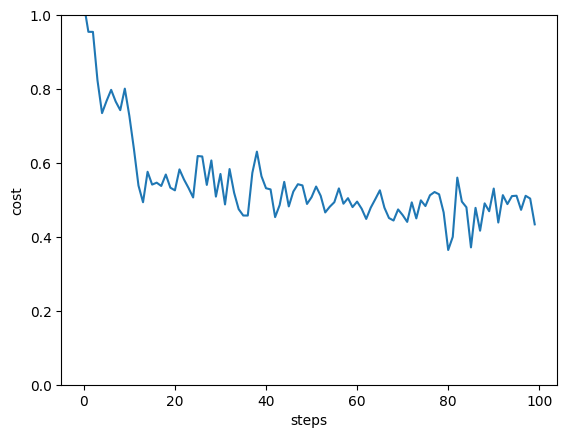

In [53]:
n_layers = 2
batch_size = 20
steps = 100

with dev_var.tracker:
    trained_params, trained_bias, loss_history = quantum_model_training(n_layers, steps, batch_size)
    pred_test = quantum_model_predict(X_test, trained_params, trained_bias)

#copy/paste:
print("accuracy on test set:", accuracy_score(pred_test, y_test))

plt.plot(loss_history)
plt.ylim((0, 1))
plt.xlabel("steps")
plt.ylabel("cost")
plt.show()

Note that the variational circuit has (slightly) lower accuracy than the SVM, but this also depends on the training settings, e.g. different random initializations, more layers, more steps (etc.) can affect test accuracy

In [54]:
#how often did we execute the device?
dev_var.tracker.totals['executions']

74025

The variational method took many more executions than the kernel method, 74K vs 7.5K

In each optimization step, the variational circuit computes the partial derivatives of all trainable parameters for each sample in a batch. Using the parameter-shift rules will require ~two circuit evaluations per partial derivative, and prediction uses only one circuit evaluation per sample

We can formulate this as another function that will be used in the scaling plot below

In [58]:
def circuit_evals_variational(n_data, n_params, n_steps, shift_terms, split, batch_size):
    """Compute how many circuit evaluations are needed 
    for variational training and prediction"""

    M = int(np.ceil(split * n_data))
    Mpred = n_data - M

    n_training = n_params * n_steps * batch_size * shift_terms

    #for prediction, we evaluate the quantum circuit on each test sample once
    n_prediction = Mpred

    return n_training + n_prediction

In [59]:
#this estimates the circuit evaluations in variational trainings as:
circuit_evals_variational(
    n_data = len(X),
    n_params = len(trained_params.flatten()),
    n_steps = steps,
    shift_terms = 2,
    split = len(X_train) / (len(X_train) + len(X_test)),
    batch_size=batch_size,
)

96025

In [60]:
circuit_evals_variational(
    n_data=len(X),
    n_params=len(trained_params.flatten()),
    n_steps=steps,
    shift_terms=2,
    split=len(X_train) / (len(X_train) + len(X_test)),
    batch_size=batch_size,
)

96025

The 96K estimate is higher than the 74K number because it does not account for some under-the-hood optimizations that PennyLane performs

It should be noted that, while the variational circuit and (classical) neural network model are trained in a similar manner, the number of evaluations is different:

In [61]:
def model_evals_nn(n_data, n_params, n_steps, split, batch_size):
    """Compute how many model evaluations are needed for NN train/preds"""

    M = int(np.ceil(split * n_data))
    Mpred = n_data - M

    n_training = n_steps * batch_size
    n_prediction = Mpred

    return n_training + n_prediction

At each step of NN training, the backpropagation algortihm can compute a gradient for all parameters in a (basically) single run. But the no-cloning principle prevents variational circuits from using these tricks [why?], which leads to `n_training` in `circuit_evals_variational` depending on number of parameters, but not in `model_evals_nn`

For the same example as used here, a NN would therefore have far fewer model evaluations than both variational and kernel-based training

In [62]:
model_evals_nn(
    n_data = len(X),
    n_params = len(trained_params.flatten()),
    n_steps = steps,
    split= len(X_train) / (len(X_train) + len(X_test)),
    batch_size=batch_size,
)

2025

## Which method scales best?
Answer depends on how the variational model is set up, and we need to make a few assumptions:
1. Even if we use single-batch stochastic gradient descent (every training step uses exactly one training sample), we would want to see every training sample at least once on average. Therefore, the nnumber of steps should scale at least linearly with the number of training data samples
2. Modern NNs often have many more parameters than training samples. But we do not know yet whether variational circuits really need as many parameters as well. We therefore use two cases for comparison:
    * The number of parameters grows linearly with the training data, i.e. `n_params = M`
    * The number of parameters saturates at some point, which we model by setting `n_params = sqrt(M)`

Note: compared with the example above which had 75 training samples and 24 parameters [it did?], the first option ($M$) overestimates the number of evaluations while the second option ($\sqrt{M}$) underestimates it

Let's compare the three methods:

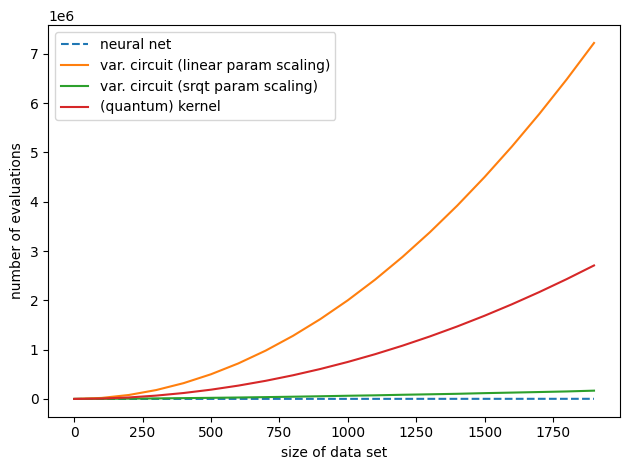

In [64]:
variational_training1 = []
variational_training2 = []
variational_training3 = []
kernelbased_training = []
nn_training = []
x_axis = range(0,2000, 100)

for M in x_axis:
    var1 = circuit_evals_variational(
        n_data=M, n_params=M, n_steps=M, 
        shift_terms=2, split=0.75, batch_size=1
    )
    variational_training1.append(var1)


    var2 = circuit_evals_variational(
        n_data=M, n_params=round(np.sqrt(M)), n_steps=M, 
        shift_terms=2, split=0.75, batch_size=1
    )
    variational_training2.append(var2)


    kernel = circuit_evals_kernel(n_data=M, split=0.75)
    kernelbased_training.append(kernel)

    nn = model_evals_nn(
        n_data=M, n_params=M, n_steps=M, 
        split=0.75, batch_size=1
    )
    nn_training.append(nn)

plt.plot(x_axis, nn_training, linestyle='--', label="neural net")
plt.plot(x_axis, variational_training1, label="var. circuit (linear param scaling)")
plt.plot(x_axis, variational_training2, label="var. circuit (srqt param scaling)")
plt.plot(x_axis, kernelbased_training, label="(quantum) kernel")
plt.xlabel("size of data set")
plt.ylabel("number of evaluations")
plt.legend()
plt.tight_layout()
plt.show()

> With current hardware-compatible training methods, whether kernel-based training requires more or fewer quantum circuit evaluations than variational training depends on how many parameters the latter needs. If variational circuits turn out to be as parameter-hungry as neural networks, kernel-based training will outperform them for common machine learning tasks. However, if variational learning only turns out to require few parameters (or if more efficient training methods are found), variational circuits could in principle match the linear scaling of neural networks trained with backpropagation.
>
>The practical take-away from this demo is that unless your variational circuit has significantly fewer parameters than training data, kernel methods could be a much faster alternative!
>
>Finally, it is important to note that fault-tolerant quantum computers may change the picture for both quantum and classical machine learning. As mentioned in Schuld (2021), early results from the quantum machine learning literature show that larger quantum computers will most likely enable us to reduce the quadratic scaling of kernel methods to linear scaling, which may make classical as well as quantum kernel methods a strong alternative to neural networks for big data processing one day.